# <center> 6. JSON. Работаем с pandas. Из JSON в pandas

## <center> ИЗ JSON В PANDAS

> После десериализации наши данные были преобразованы в список, элементами которого являются вложенные словари, содержащие по три пары "ключ-значение". 

Поскольку структура всех вложенных словарей одинакова, мы можем создать DataFrame на основе списка, не проводя с ним никаких дополнительных манипуляций:



In [1]:
import pandas as pd
import numpy as np
import json
from pprint import pprint

In [3]:
with open('data/recipes.json') as f: # Открываем файл и связываем его с объектом "f"
    recipes = json.load(f) # Загружаем содержимое открытого файла в переменную recipes
df = pd.DataFrame(recipes) # Создаём объект DataFrame из списка recipes
display(df.head()) # Выводим на экран первые строки полученного DataFrame

,id,cuisine,ingredients
0,10259,greek,"[romaine lettuce, black olives, grape tomatoes..."
1,25693,southern_us,"[plain flour, ground pepper, salt, tomatoes, g..."
2,20130,filipino,"[eggs, pepper, salt, mayonaise, cooking oil, g..."
3,22213,indian,"[water, vegetable oil, wheat, salt]"
4,13162,indian,"[black pepper, shallots, cornflour, cayenne pe..."


#### <center> ДОПОЛНИТЕЛЬНО

Для непосредственного считывания содержимого файла recipes.json в переменную df (объект DataFrame) используйте функцию read_json() (с англ. читать_json).

In [ ]:
df = pd.read_json('data/recipes.json') # Создаём объект DataFrame, загружая содержимое файла recipes.json
display(df.head()) # Выводим на экран первые строки полученного DataFrame

Для более подробного ознакомления с функцией  read_json() предлагаем вам обратиться к [документации](https://pandas.pydata.org/pandas-docs/version/1.1.3/reference/api/pandas.read_json.html).

>Итак, получившийся DataFrame содержит информацию о рецептах из нашего JSON-файла. 

Каждая строка соответствует одному рецепту, в столбце id хранится его идентификационный номер, в столбце cuisine — тип кухни, а столбец ingredients содержит список, в котором перечислены ингредиенты, необходимые для приготовления блюда.

>Такая структура не очень практична, поскольку она не позволяет осуществлять группировку данных и выполнять многие другие операции, связанные с исследованием ингредиентов разных блюд. Например, представьте, что вы хотите отфильтровать блюда, состоящие не более чем из пяти ингредиентов, или блюда, не содержащие мяса. Сделать это, когда ингредиенты блюд хранятся в списках, не очень просто.

Для полноценной работы с данными нам необходимо иметь возможность хранить информацию о каждом ингредиенте в отдельном столбце, например:

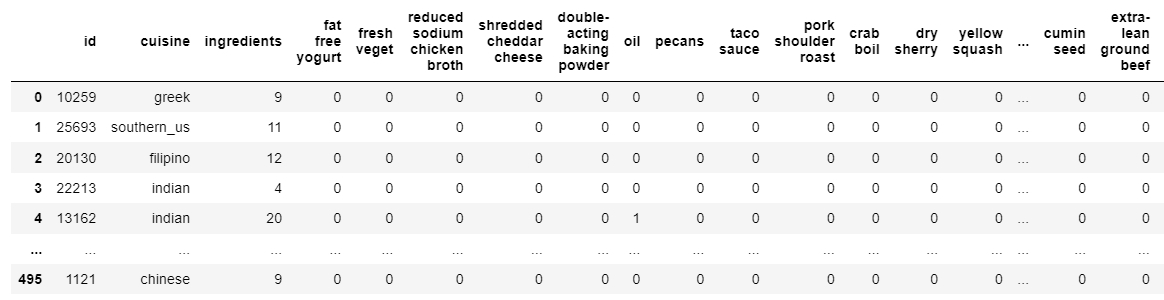

Давайте шаг за шагом преобразуем DataFrame в такой вид.

Работу над преобразованием DataFrame начнём с создания и заполнения столбцов, содержащих сведения о наличии или отсутствии каждого ингредиента в рецепте. Процесс заполнения выполним в два этапа:

1. Создадим функцию для заполнения значения в каждой ячейке. Функция будет проверять наличие конкретного ингредиента в столбце ingredients для текущего блюда и возвращать 1, если ингредиент есть в рецепте, и 0, если он отсутствует.

2. Организуем цикл, в котором будем перебирать наименования всех ингредиентов DataFrame (для этого потребуется создать реестр, то есть некий список, который содержит уникальные наименования ингредиентов). Для каждого ингредиента создадим в DataFrame столбец с соответствующим названием и заполним его единицами и нулями, применив к DataFrame, а точнее к столбцу ingredients функцию, созданную нами на предыдущем этапе.

In [4]:
all_ingredients=set() # Создаем пустое множество для хранения реестра уникальных ингредиентов
for recipe in recipes: # Начинаем перебор всех блюд входящих в список
    for ingredient in recipe['ingredients']: # Начинаем перебор всех ингредиентов входящих в состав текущего блюда
        all_ingredients.add(ingredient ) # Добавляем уникальный ингредиент в реестр
display(len(all_ingredients)) # Выводим на экран количество уникальных ингредиентов из реестра

1318

> Теперь определим функцию contains(), с помощью которой мы будем проверять наличие конкретного ингредиента ingredient_name в рецепте текущего блюда, который представлен списком ingredient_list (значение в ячейке столбца ingredients текущего рецепта).

 Функция будет возвращать 1, если ингредиент есть в рецепте, и 0, если он отсутствует:

In [5]:
def contains(ingredient_list): # Определяем имя функции и передаваемые аргументы
    if ingredient_name in ingredient_list: # Если ингредиент есть в текущем блюде,
        return 1 # возвращаем значение 1
    else: # Если ингредиента нет в текущем блюде,
        return 0 # возвращаем значение 0

Отлично! Осталось лишь перебрать все ингредиенты из ранее созданного реестра all_ingredients с помощью цикла  for  и создать в DataFrame столбец с соответствующим названием, заполнив его единицами и нулями. Для этого применим к DataFrame, а точнее, к столбцу ingredients функцию contains().

In [6]:
for ingredient_name in all_ingredients: # Последовательно перебираем ингредиенты в реестре all_ingredients
    df[ingredient_name] = df['ingredients'].apply(contains) # В DataFrame cоздаем столбец с именем текущего ингредиента и заполняем его единицами и нулями, используя ранее созданную функцию contains

C:\Users\Zylno\AppData\Local\Temp\ipykernel_14744\2944465906.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[ingredient_name] = df['ingredients'].apply(contains) # В DataFrame cоздаем столбец с именем текущего ингредиента и заполняем его единицами и нулями, используя ранее созданную функцию contains
C:\Users\Zylno\AppData\Local\Temp\ipykernel_14744\2944465906.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[ingredient_name] = df['ingredients'].apply(contains) # В DataFrame cоздаем столбец с именем текущего ингредиен

В завершение изменим значение столбца ingredients — вместо списка ингредиентов в каждом рецепте заполним столбец данными о количестве ингредиентов в нём:

In [7]:
df['ingredients'] = df['ingredients'].apply(len) # Заменяем список ингредиентов в рецепте на их количество 
display(df) # Выводим содержимое полученного DataFrame на экран

,id,cuisine,ingredients,olive oil cooking spray,Turkish bay leaves,extra sharp cheddar cheese,whole milk ricotta cheese,smoked ham hocks,orange blossom honey,curry leaves,...,frozen corn,tofu,kashmiri chile,nonstick spray,extra-virgin olive oil,grapefruit juice,ground cloves,chicken,tomatoes,dry red wine
0,10259,greek,9,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,25693,southern_us,11,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,20130,filipino,12,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,22213,indian,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,13162,indian,20,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1121,chinese,9,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
496,18376,italian,8,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
497,17815,italian,8,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
498,32878,southern_us,19,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Задание 6.5

Напишите код для создания списка ids всех блюд, представленных в датафрейме. Нужны только уникальные значения.

Порядок id должен совпадать с тем, как они расположены в исходном датафрейме.

Примечание. Не забудьте импортировать библиотеки и прочитать файл recipes.csv.

In [29]:
ids = [] # создаём пустой список для хранения уникальных значений кухонь
for elem in recipes:  # начинаем перебор всех рецептов
    ids.append(elem['id']) # добавляем название типа кухни к множеству
        
display(ids)

[10259,
 25693,
 20130,
 22213,
 13162,
 6602,
 42779,
 3735,
 16903,
 12734,
 5875,
 45887,
 2698,
 41995,
 31908,
 24717,
 34466,
 1420,
 2941,
 8152,
 13121,
 40523,
 40989,
 29630,
 49136,
 26705,
 27976,
 22087,
 9197,
 1299,
 40429,
 34419,
 10276,
 33465,
 39250,
 37963,
 20051,
 11300,
 17610,
 37405,
 28302,
 31634,
 32304,
 36341,
 29369,
 27564,
 18515,
 3335,
 4499,
 4906,
 5767,
 30748,
 35930,
 44902,
 31119,
 3535,
 47028,
 38112,
 2646,
 5206,
 38233,
 39267,
 11913,
 20591,
 70,
 43928,
 8530,
 275,
 43769,
 49111,
 11886,
 45839,
 699,
 24568,
 8820,
 16582,
 9058,
 4715,
 29061,
 2107,
 22825,
 13758,
 6886,
 14874,
 43399,
 38254,
 41596,
 33989,
 17004,
 4969,
 31831,
 46648,
 36888,
 34471,
 25164,
 39600,
 46357,
 46905,
 8753,
 37337,
 17636,
 8997,
 28851,
 4635,
 7782,
 8031,
 49434,
 31318,
 31027,
 47095,
 4574,
 19757,
 35570,
 44812,
 27858,
 18624,
 9406,
 35132,
 33071,
 8321,
 20955,
 45776,
 6043,
 336,
 25751,
 793,
 34367,
 7406,
 7473,
 7532,
 5924,

## <center> СОХРАНЯЕМ DATAFRAME В CSV-ФАЙЛЕ

Если мы планируем продолжать работать с DataFrame, созданными на основе данных, которые мы получили в JSON-формате, то полезно будет сохранить промежуточный DataFrame в виде CSV-файла. Для выполнения этой операции воспользуемся известной нам в Pandas функцией to_csv():

In [30]:
df.to_csv('data/recipes.csv', index = False)

В качестве основного параметра мы указали имя файла, в котором необходимо сохранить данные. Также мы установили значение параметра index как False. Такая настройка позволит нам не сохранять индексы строк в виде отдельного столбца; в результате не будут загружаться «лишние» данные при открытии файла при помощи функции read_csv().